In [244]:
from utils.DataPreprocessing import dataloader
from loguru import logger
import os
import polars as pl
lag = 20 # number of previous time steps to consider
n_features = 15 # number of features
n_steps_out = 1 # number of output steps (how many future steps are we going to predict?)

n_epochs = 60 # 1000 epochs
learning_rate = 0.01 # 0.001 lr

hidden_size = 100 # number of features in hidden state
num_layers = 1 # number of stacked lstm layers

path = os.path.dirname(os.path.dirname(os.getcwd()))
print(path)
data = dataloader(path=path, lag=lag)

2024-04-14 02:43:14.108 | INFO     | utils.DataPreprocessing:load_csv:129 - shape: (11_103, 3)
┌───────────┬─────────────┬────────────┐
│ AVG_TEMP  ┆ AVG_TEMP_DC ┆ date       │
│ ---       ┆ ---         ┆ ---        │
│ f32       ┆ str         ┆ date       │
╞═══════════╪═════════════╪════════════╡
│ 29.299999 ┆ C           ┆ 1992-07-01 │
│ 29.200001 ┆ C           ┆ 1992-07-02 │
│ 29.6      ┆ C           ┆ 1992-07-03 │
│ 29.299999 ┆ C           ┆ 1992-07-04 │
│ 29.299999 ┆ C           ┆ 1992-07-05 │
│ …         ┆ …           ┆ …          │
│ 22.200001 ┆ C           ┆ 2022-11-26 │
│ 22.4      ┆ C           ┆ 2022-11-27 │
│ 25.4      ┆ C           ┆ 2022-11-28 │
│ 25.1      ┆ C           ┆ 2022-11-29 │
│ 22.1      ┆ C           ┆ 2022-11-30 │
└───────────┴─────────────┴────────────┘
2024-04-14 02:43:14.110 | INFO     | utils.DataPreprocessing:load_csv:131 - shape: (1, 3)
┌──────────┬─────────────┬──────┐
│ AVG_TEMP ┆ AVG_TEMP_DC ┆ date │
│ ---      ┆ ---         ┆ ---  │
│ u32      ┆ u32

/home/argonaut/programming/HK-Temperature-Forecasting


In [245]:
import numpy as np
import matplotlib.pyplot as plt
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS
from datetime import datetime

time_train_df = pl.datetime_range(
    datetime(data.start_date.year, data.start_date.month, data.start_date.day), 
    datetime(2018, 3, 31), 
    "1d", eager=True
).alias("datetime")

time_test_df = pl.datetime_range(
    datetime(2018, 4, 1), 
    datetime(data.end_date.year, data.end_date.month, data.end_date.day), 
    "1d", eager=True
).alias("datetime")

print(time_train_df)
print(time_test_df)

shape: (6_818,)
Series: 'datetime' [datetime[μs]]
[
	1999-08-01 00:00:00
	1999-08-02 00:00:00
	1999-08-03 00:00:00
	1999-08-04 00:00:00
	1999-08-05 00:00:00
	…
	2018-03-27 00:00:00
	2018-03-28 00:00:00
	2018-03-29 00:00:00
	2018-03-30 00:00:00
	2018-03-31 00:00:00
]
shape: (1_705,)
Series: 'datetime' [datetime[μs]]
[
	2018-04-01 00:00:00
	2018-04-02 00:00:00
	2018-04-03 00:00:00
	2018-04-04 00:00:00
	2018-04-05 00:00:00
	…
	2022-11-26 00:00:00
	2022-11-27 00:00:00
	2022-11-28 00:00:00
	2022-11-29 00:00:00
	2022-11-30 00:00:00
]


In [246]:
Y_train_df = pl.DataFrame(data.train)
category_array = np.full(len(Y_train_df), 1, dtype=int)
Y_train_df = Y_train_df.with_columns([time_train_df.alias("date"),
                                      pl.Series(category_array).alias('unique_id')])
Y_train_df = Y_train_df.rename({"date": "ds",
                 "AVG_TEMP": "y"})
print(Y_train_df)

shape: (6_818, 17)
┌───────────┬────────────────┬───────────┬──────┬───┬────────────┬───────────┬─────────┬───────────┐
│ y         ┆ ds             ┆ GSR       ┆ SUN  ┆ … ┆ weekofyear ┆ dayofyear ┆ quarter ┆ unique_id │
│ ---       ┆ ---            ┆ ---       ┆ ---  ┆   ┆ ---        ┆ ---       ┆ ---     ┆ ---       │
│ f32       ┆ datetime[μs]   ┆ f32       ┆ f32  ┆   ┆ f32        ┆ f32       ┆ f32     ┆ i64       │
╞═══════════╪════════════════╪═══════════╪══════╪═══╪════════════╪═══════════╪═════════╪═══════════╡
│ 29.200001 ┆ 1999-08-01     ┆ 25.1      ┆ 11.6 ┆ … ┆ 30.0       ┆ 213.0     ┆ 3.0     ┆ 1         │
│           ┆ 00:00:00       ┆           ┆      ┆   ┆            ┆           ┆         ┆           │
│ 29.1      ┆ 1999-08-02     ┆ 15.13     ┆ 7.0  ┆ … ┆ 31.0       ┆ 214.0     ┆ 3.0     ┆ 1         │
│           ┆ 00:00:00       ┆           ┆      ┆   ┆            ┆           ┆         ┆           │
│ 29.0      ┆ 1999-08-03     ┆ 11.85     ┆ 2.4  ┆ … ┆ 31.0       ┆ 215.0

In [247]:
Y_test_df = pl.DataFrame(data.test)
category_array = np.full(len(Y_test_df), 1, dtype=int)
Y_test_df = Y_test_df.with_columns([time_test_df.alias("date"),
                                      pl.Series(category_array).alias('unique_id')])
Y_test_df = Y_test_df.rename({"date": "ds",
                 "AVG_TEMP": "y"})
print(Y_test_df)

shape: (1_705, 17)
┌───────────┬────────────────┬───────────┬──────┬───┬────────────┬───────────┬─────────┬───────────┐
│ y         ┆ ds             ┆ GSR       ┆ SUN  ┆ … ┆ weekofyear ┆ dayofyear ┆ quarter ┆ unique_id │
│ ---       ┆ ---            ┆ ---       ┆ ---  ┆   ┆ ---        ┆ ---       ┆ ---     ┆ ---       │
│ f32       ┆ datetime[μs]   ┆ f32       ┆ f32  ┆   ┆ f32        ┆ f32       ┆ f32     ┆ i64       │
╞═══════════╪════════════════╪═══════════╪══════╪═══╪════════════╪═══════════╪═════════╪═══════════╡
│ 22.9      ┆ 2018-04-01     ┆ 22.33     ┆ 9.7  ┆ … ┆ 13.0       ┆ 91.0      ┆ 2.0     ┆ 1         │
│           ┆ 00:00:00       ┆           ┆      ┆   ┆            ┆           ┆         ┆           │
│ 23.5      ┆ 2018-04-02     ┆ 21.41     ┆ 10.4 ┆ … ┆ 14.0       ┆ 92.0      ┆ 2.0     ┆ 1         │
│           ┆ 00:00:00       ┆           ┆      ┆   ┆            ┆           ┆         ┆           │
│ 24.0      ┆ 2018-04-03     ┆ 24.17     ┆ 10.8 ┆ … ┆ 14.0       ┆ 93.0 

In [248]:
from neuralforecast.models import PatchTST
from neuralforecast.losses.pytorch import MAE

import warnings
warnings.filterwarnings('ignore')

# Fit and predict with NBEATS and NHITS models
horizon = len(Y_test_df)
models = [
  # NBEATS(input_size=2 * horizon, h=horizon, max_steps=70),
  # NHITS(input_size=2 * horizon, h=horizon, max_steps=70),
  PatchTST(
    h=horizon,
    input_size=2 * horizon,
    # h=n_steps_out,
    # input_size=lag,
    patch_len=32,
    stride=32,
    revin=False,
    hidden_size=16,
    n_heads=4,
    scaler_type="robust",
    # loss=DistributionLoss(distribution="StudentT", level=[80, 90]),
    loss=MAE(),
    learning_rate=1e-3,
    max_steps=500,
    # val_check_steps=50,
    # early_stop_patience_steps=3,
  )
]
nf = NeuralForecast(models=models, freq='1d')
nf.fit(df=Y_train_df)
Y_hat_df = nf.predict().to_pandas().reset_index()
Y_test_df = Y_test_df.to_pandas().reset_index()


Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type              | Params
---------------------------------------------------
0 | loss         | MAE               | 0     
1 | padder_train | ConstantPad1d     | 0     
2 | scaler       | TemporalNorm      | 0     
3 | model        | PatchTST_backbone | 3.0 M 
---------------------------------------------------
3.0 M     Trainable params
3         Non-trainable params
3.0 M     Total params
11.807    Total estimated model params size (MB)


Epoch 499: 100%|██████████| 1/1 [00:00<00:00,  8.52it/s, v_num=74, train_loss_step=0.269, train_loss_epoch=0.269]

`Trainer.fit` stopped: `max_steps=500` reached.


Epoch 499: 100%|██████████| 1/1 [00:00<00:00,  8.29it/s, v_num=74, train_loss_step=0.269, train_loss_epoch=0.269]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 85.53it/s]


In [255]:
import pandas as pd
# Plot predictions
Y_hat_df = Y_test_df.merge(Y_hat_df, how='left', on=['unique_id', 'ds'])
Y_train_df, Y_hat_df = pd.DataFrame(Y_train_df), pd.DataFrame(Y_hat_df)

plot_df = pd.concat([Y_train_df, Y_hat_df]).set_index('ds')

In [256]:
print(plot_df)

                    0             1      2     3     4    5     6    7    8  \
ds                                                                            
NaT         29.200001  9.334656e+14  25.10  11.6  79.0  7.0   0.5  8.6  1.0   
NaT         29.100000  9.335520e+14  15.13   7.0  82.0  3.0  30.5  4.1  1.0   
NaT         29.000000  9.336384e+14  11.85   2.4  83.0  3.0   0.0  5.3  1.0   
NaT         27.500000  9.337248e+14  10.67   2.3  87.0  3.0  35.0  9.1  1.0   
NaT         27.900000  9.338112e+14  15.18   6.0  82.0  4.0  55.0  7.8  1.0   
...               ...           ...    ...   ...   ...  ...   ...  ...  ...   
2022-11-26        NaN           NaN    NaN   NaN   NaN  NaN   NaN  NaN  NaN   
2022-11-27        NaN           NaN    NaN   NaN   NaN  NaN   NaN  NaN  NaN   
2022-11-28        NaN           NaN    NaN   NaN   NaN  NaN   NaN  NaN  NaN   
2022-11-29        NaN           NaN    NaN   NaN   NaN  NaN   NaN  NaN  NaN   
2022-11-30        NaN           NaN    NaN   NaN   N

In [257]:
# get the null count
null_count = plot_df.isnull().sum()
print(null_count)

0               1705
1               1705
2               1705
3               1705
4               1705
5               1705
6               1705
7               1705
8               1705
9               1705
10              1705
11              1705
12              1705
13              1705
14              1705
15              1705
16              1705
index           6818
y_x             6818
GSR_x           6818
SUN_x           6818
RH_x            6818
UV_x            6818
RF_x            6818
WSPD_x          6818
weather_x       6818
dayofweek_x     6818
Month_x         6818
year_x          6818
dayofmonth_x    6818
weekofyear_x    6818
dayofyear_x     6818
quarter_x       6818
unique_id       6818
index_x         6818
y_y             6818
GSR_y           6818
SUN_y           6818
RH_y            6818
UV_y            6818
RF_y            6818
WSPD_y          6818
weather_y       6818
dayofweek_y     6818
Month_y         6818
year_y          6818
dayofmonth_y    6818
weekofyear_y 

In [258]:
# for the plot dataframe, drop the rows with null values in column 'PatchTST'
plot_df = plot_df.dropna(subset=['PatchTST'])

In [260]:
# get the r2 score, mse, and mae
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

r2 = r2_score(plot_df['y_y'], plot_df['PatchTST'])
mse = mean_squared_error(plot_df['y_y'], plot_df['PatchTST'])
mae = mean_absolute_error(plot_df['y_y'], plot_df['PatchTST'])
print(f"R2: {r2}, MSE: {mse}, MAE: {mae}")

R2: 0.6722358598810037, MSE: 7.210666179656982, MAE: 2.1300954818725586


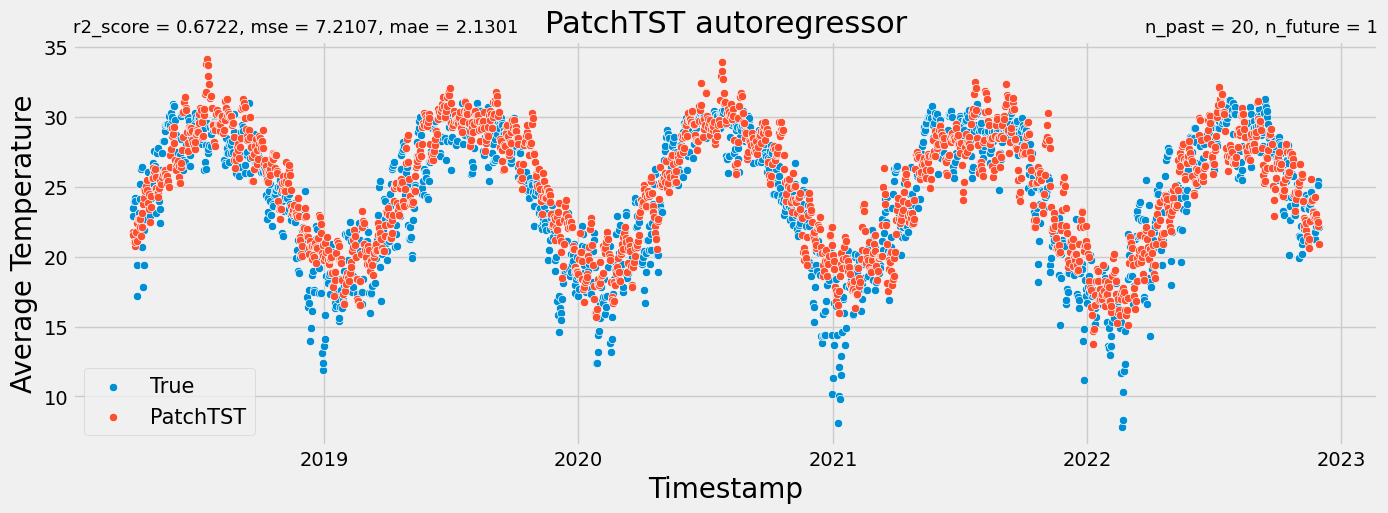

In [262]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize = (15, 5))

sns.scatterplot(x=plot_df.index, y=plot_df['y_y'], ax=ax, label="True")
sns.scatterplot(x=plot_df.index, y=plot_df['PatchTST'], ax=ax, label="PatchTST")
# sns.scatterplot(x=plot_df.index, y=plot_df['NBEATS'], ax=ax, label="NBEATS")
# sns.scatterplot(x=plot_df.index, y=plot_df['NHITS'], ax=ax, label="NHITS")

ax.set_title('PatchTST autoregressor', fontsize=22)
ax.set_title(f"n_past = {lag:}, n_future = {n_steps_out}", loc="right", fontsize=13)
ax.set_title(f"r2_score = {r2:1.4f}, mse = {mse:1.4f}, mae = {mae:1.4f}", loc="left", fontsize=13)

ax.set_ylabel('Average Temperature', fontsize=20)
ax.set_xlabel('Timestamp', fontsize=20)
ax.legend(prop={'size': 15})
ax.grid()
plt.grid()
plt.savefig("patchtst.png")
# plt.show()
